# Notebook 01 — EDA & Data Quality Audit

Three NYRA tables, each with a different structure and scale:

- `nyra_race_table.csv`: one row per race (track, distance, conditions, purse)
- `nyra_start_table.csv`: one row per horse per race (jockey, weight, odds, finish position)
- `nyra_tracking_table.csv`: GPS tracking at ~4 times per second for every horse in every race

First pass: load them, check that they're structurally sound, clean anything that needs it. Clean versions get saved as Parquet files in `data/processed/`.

## 0. Setup

In [1]:
import duckdb
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

RAW_DATA_DIR = Path("../data/raw")
PROCESSED_DATA_DIR = Path("../data/processed")
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

## 1. First look at the data

Checking file sizes first, for all three tables, before loading anything.

In [2]:
for filename in ["nyra_race_table.csv", "nyra_start_table.csv", "nyra_tracking_table.csv"]:
    size_mb = (RAW_DATA_DIR / filename).stat().st_size / 1e6
    print(f"{filename}: {size_mb:.1f} MB")

nyra_race_table.csv: 0.1 MB
nyra_start_table.csv: 0.7 MB
nyra_tracking_table.csv: 336.3 MB


The tracking file is much bigger than the other two. Keeping that in mind for when we get to it.

### 1.1 Race table

In [3]:
race = pd.read_csv(RAW_DATA_DIR / "nyra_race_table.csv", parse_dates=["race_date"])
race.head()

,track_id,race_date,race_number,distance_id,course_type,track_condition,run_up_distance,race_type,purse,post_time
0,AQU,2019-01-01,1,650,D,MY,36,AOC,80000,1220
1,AQU,2019-01-01,2,600,D,MY,48,MCL,41000,1250
2,AQU,2019-01-01,3,550,D,MY,54,MCL,35000,121
3,AQU,2019-01-01,4,900,D,MY,101,AOC,80000,150
4,AQU,2019-01-01,5,700,D,MY,60,ALW,64000,220


In [4]:
race.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   track_id         2000 non-null   str           
 1   race_date        2000 non-null   datetime64[us]
 2   race_number      2000 non-null   int64         
 3   distance_id      2000 non-null   int64         
 4   course_type      2000 non-null   str           
 5   track_condition  2000 non-null   str           
 6   run_up_distance  2000 non-null   int64         
 7   race_type        2000 non-null   str           
 8   purse            2000 non-null   int64         
 9   post_time        2000 non-null   int64         
dtypes: datetime64[us](1), int64(5), str(4)
memory usage: 175.9 KB


In [5]:
for col in ["track_id", "course_type", "track_condition", "race_type"]:
    print(col, race[col].unique())

track_id <ArrowStringArray>
['AQU', 'BEL', 'SAR']
Length: 3, dtype: str
course_type <ArrowStringArray>
['D', 'O', 'T', 'I', 'M']
Length: 5, dtype: str
track_condition <ArrowStringArray>
['MY ', 'GD ', 'FT ', 'SY ', 'FM ', 'YL ', 'SF ']
Length: 7, dtype: str
race_type <ArrowStringArray>
['AOC', 'MCL', 'ALW', 'STK', 'CLM', 'MSW', 'STR', 'SOC', 'SHP', 'WCL', 'SST',
 'WMC']
Length: 12, dtype: str


Loads cleanly. Categories match the docs. One thing: `track_condition` has trailing spaces on every value (e.g. "MY " instead of "MY"). Will strip those when we hit text cleaning.

### 1.2 Start table

In [6]:
start = pd.read_csv(RAW_DATA_DIR / "nyra_start_table.csv")
start.head()

,AQU,2019-01-01,1,1,123,Dylan Davis,130,2
0,AQU,2019-01-01,1,2,120,Junior Alvarado,295,3
1,AQU,2019-01-01,1,3,118,Jose Lezcano,180,4
2,AQU,2019-01-01,1,4,123,Jomar Garcia,1280,5
3,AQU,2019-01-01,1,5,118,Manuel Franco,1150,1
4,AQU,2019-01-01,2,1,121,Jose Lezcano,220,2


The column names are clearly the values from what should be the first data row, this file doesn't have a real header. Fixing that using the column order from the challenge documentation.

In [7]:
start_columns = [
    "track_id", 
    "race_date", 
    "race_number", 
    "program_number",
    "weight_carried", 
    "jockey", 
    "odds", 
    "position_at_finish"
]

start = pd.read_csv(
    RAW_DATA_DIR / "nyra_start_table.csv",
    header=None,
    names=start_columns,
    parse_dates=["race_date"],
)
start.head()

,track_id,race_date,race_number,program_number,weight_carried,jockey,odds,position_at_finish
0,AQU,2019-01-01,1,1,123,Dylan Davis,130,2
1,AQU,2019-01-01,1,2,120,Junior Alvarado,295,3
2,AQU,2019-01-01,1,3,118,Jose Lezcano,180,4
3,AQU,2019-01-01,1,4,123,Jomar Garcia,1280,5
4,AQU,2019-01-01,1,5,118,Manuel Franco,1150,1


In [8]:
start.info()

<class 'pandas.DataFrame'>
RangeIndex: 14915 entries, 0 to 14914
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   track_id            14915 non-null  str           
 1   race_date           14915 non-null  datetime64[us]
 2   race_number         14915 non-null  int64         
 3   program_number      14915 non-null  str           
 4   weight_carried      14915 non-null  int64         
 5   jockey              14915 non-null  str           
 6   odds                14915 non-null  int64         
 7   position_at_finish  14915 non-null  int64         
dtypes: datetime64[us](1), int64(4), str(3)
memory usage: 1.2 MB


In [9]:
start["track_id"].unique()

<ArrowStringArray>
['AQU', 'BEL', 'SAR']
Length: 3, dtype: str

3 track_ids, matching AQU/BEL/SAR from the documentation. Header issue fixed, nothing else off here.

### 1.3 Tracking table

At ~340MB, loading this fully into pandas just to look at it isn't efficient, querying it directly with SQL via DuckDB instead.

In [10]:
con = duckdb.connect()

row_count = con.sql(f"""
    SELECT COUNT(*) AS n_rows
    FROM read_csv_auto('{RAW_DATA_DIR}/nyra_tracking_table.csv')
""").df()
print(row_count)

    n_rows
0  5228430


In [11]:
tracking = con.sql(f"""
    SELECT * FROM read_csv_auto('{RAW_DATA_DIR}/nyra_tracking_table.csv')
    LIMIT 5
""").df()
tracking

,track_id,race_date,race_number,program_number,trakus_index,latitude,longitude
0,AQU,2019-01-01,9,6,72,40.672902,-73.827607
1,AQU,2019-01-01,9,6,73,40.672946,-73.827587
2,AQU,2019-01-01,9,6,74,40.672990,-73.827568
3,AQU,2019-01-01,9,6,63,40.672510,-73.827781
4,AQU,2019-01-01,9,6,64,40.672553,-73.827762


## 2. Structural integrity check

### 2.1 Shape

In [12]:
print("race shape:", race.shape)
print("start shape:", start.shape)

race shape: (2000, 10)
start shape: (14915, 8)


### 2.2 Missing values

In [13]:
race.isnull().sum()

track_id           0
race_date          0
race_number        0
distance_id        0
course_type        0
track_condition    0
run_up_distance    0
race_type          0
purse              0
post_time          0
dtype: int64

In [14]:
start.isnull().sum()

track_id              0
race_date             0
race_number           0
program_number        0
weight_carried        0
jockey                0
odds                  0
position_at_finish    0
dtype: int64

In [15]:
nulls_tracking = con.sql(f"""
    SELECT
        sum(case when track_id is null then 1 else 0 end) as track_id_nulls,
        sum(case when program_number is null then 1 else 0 end) as program_number_nulls,
        sum(case when trakus_index is null then 1 else 0 end) as trakus_index_nulls,
        sum(case when latitude is null then 1 else 0 end) as latitude_nulls,
        sum(case when longitude is null then 1 else 0 end) as longitude_nulls
    FROM read_csv_auto('{RAW_DATA_DIR}/nyra_tracking_table.csv')
""").df()
nulls_tracking

,track_id_nulls,program_number_nulls,trakus_index_nulls,latitude_nulls,longitude_nulls
0,0.0,0.0,0.0,0.0,0.0


No missing values in any of the three tables.

### 2.3 Duplicate keys

Checking for duplicate rows based on what should be the unique key of each table.

In [16]:
race.duplicated(subset=["track_id", "race_date", "race_number"]).sum()

np.int64(0)

In [17]:
start.duplicated(subset=["track_id", "race_date", "race_number", "program_number"]).sum()

np.int64(0)

In [18]:
dup_check_tracking = con.sql(f"""
    SELECT
        count(*) as total_rows,
        count(distinct (track_id, race_date, race_number, program_number, trakus_index)) as unique_keys
    FROM read_csv_auto('{RAW_DATA_DIR}/nyra_tracking_table.csv')
""").df()
dup_check_tracking

,total_rows,unique_keys
0,5228430,5228430


No duplicates in any of the three tables.

### 2.4 Referential integrity

Checking that the three tables actually connect properly. Every race referenced in `start` should exist in `race`, and every horse-race in `start` should have matching tracking data.

In [19]:
race_keys = race[["track_id", "race_date", "race_number"]].drop_duplicates()
start_keys = start[["track_id", "race_date", "race_number"]].drop_duplicates()

check = start_keys.merge(race_keys, on=["track_id", "race_date", "race_number"], how="left", indicator=True)
check["_merge"].value_counts()

_merge
both          2000
left_only        0
right_only       0
Name: count, dtype: int64

In [20]:
orphans = con.sql(f"""
    SELECT count(*) as start_rows_without_tracking
    FROM start s
    LEFT JOIN (
        SELECT DISTINCT track_id, race_date, race_number, program_number
        FROM read_csv_auto('{RAW_DATA_DIR}/nyra_tracking_table.csv')
    ) t
    ON s.track_id = t.track_id AND s.race_date = t.race_date
       AND s.race_number = t.race_number AND s.program_number = t.program_number
    WHERE t.track_id IS NULL
""").df()
orphans

,start_rows_without_tracking
0,0


Every race referenced in `start` exists in `race`, and every horse-race in `start` has matching tracking data. The three tables join cleanly.

## 3. Text cleaning

Checking all text columns across the three tables for whitespace issues, instead of relying on eyeballing unique values.

In [21]:
for col in race.select_dtypes(include=["object", "string"]).columns:
    n = (race[col].str.strip() != race[col]).sum()
    print(f"race.{col}: {n} with whitespace")

for col in start.select_dtypes(include=["object", "string"]).columns:
    n = (start[col].str.strip() != start[col]).sum()
    print(f"start.{col}: {n} with whitespace")

race.track_id: 0 with whitespace
race.course_type: 0 with whitespace
race.track_condition: 2000 with whitespace
race.race_type: 0 with whitespace
start.track_id: 0 with whitespace
start.program_number: 14915 with whitespace
start.jockey: 0 with whitespace


In [22]:
con.sql(f"""
    SELECT
        sum(case when track_id != trim(track_id) then 1 else 0 end) as track_id_ws,
        sum(case when program_number != trim(program_number) then 1 else 0 end) as program_number_ws
    FROM read_csv_auto('{RAW_DATA_DIR}/nyra_tracking_table.csv')
""").df()

,track_id_ws,program_number_ws
0,0.0,5228430.0


Two issues, both hitting every single row. `race.track_condition` has a trailing space on all 2,000 entries. `program_number` is a fixed-width field (e.g. "1  ", "1A "), padded consistently across `start` and `tracking`, which is why the joins above still worked. Worth stripping now so future joins don't break silently.

In [23]:
race["track_condition"] = race["track_condition"].str.strip()
start["program_number"] = start["program_number"].str.strip()

race["track_condition"].unique()

<ArrowStringArray>
['MY', 'GD', 'FT', 'SY', 'FM', 'YL', 'SF']
Length: 7, dtype: str

In [24]:
start["program_number"].unique()[:10]

<ArrowStringArray>
['1', '2', '3', '4', '5', '6', '7', '8', '1A', '10']
Length: 10, dtype: str

`tracking.program_number` isn't loaded into a DataFrame yet (we've been querying the file directly), so there's nothing to fix here right now. Just something to remember: apply `trim(program_number)` whenever we pull it from that file in later notebooks.

## 4. Numeric range checks

Going column by column through the key numeric fields, checking for values that don't make sense given what they represent.

### 4.1 Odds

In [25]:
start["odds"].describe()

count    14915.000000
mean      1483.496480
std       1956.137156
min          0.000000
25%        335.000000
50%        730.000000
75%       1740.000000
max      19100.000000
Name: odds, dtype: float64

Minimum is 0. In pari-mutuel betting, odds of 0 isn't a real market price. The lowest real odds is typically around "1 to 5". These look more like missing values recorded as 0 than genuine prices.

In [26]:
(start["odds"] == 0).sum()

np.int64(3)

In [27]:
start[start["odds"] == 0]

,track_id,race_date,race_number,program_number,weight_carried,jockey,odds,position_at_finish
3004,AQU,2019-04-11,5,2B,122,Manuel Franco,0,1
4018,AQU,2019-11-10,5,11,119,Kendrick Carmouche,0,10
6867,BEL,2019-05-12,3,3,118,Kendrick Carmouche,0,1


3 rows. Flagging these to exclude from any market-efficiency analysis later, rather than treating them as real extreme-favorite prices.

### 4.2 Weight and finishing position

In [28]:
start[["weight_carried", "position_at_finish"]].describe()

,weight_carried,position_at_finish
count,14915.000000,14915.000000
mean,120.454040,4.486088
std,3.522007,2.569144
min,110.000000,1.000000
25%,118.000000,2.000000
50%,120.000000,4.000000
75%,122.000000,6.000000
max,160.000000,14.000000


Both ranges look plausible. No negative weights, no impossible finishing positions.

### 4.3 Race table numeric fields

In [29]:
race[["distance_id", "run_up_distance", "purse"]].describe()

,distance_id,run_up_distance,purse
count,2000.000000,2000.000000,2.000000e+03
mean,725.850000,65.650000,8.252010e+04
std,148.189938,36.111446,1.061118e+05
min,450.000000,0.000000,1.600000e+04
25%,600.000000,45.000000,4.200000e+04
50%,700.000000,54.000000,6.200000e+04
75%,800.000000,76.000000,8.000000e+04
max,2000.000000,280.000000,1.500000e+06


All ranges look reasonable here too.

### 4.4 program_number suffixes

Looking back at the unique program_number values from Section 3, some weren't plain numbers. Things like "1A", "3X". Worth checking how common that is.

In [30]:
has_letter = start["program_number"].str.contains(r"[A-Za-z]")
has_letter.sum()

np.int64(177)

In [31]:
start.loc[has_letter, "program_number"].unique()

<ArrowStringArray>
['1A', '2B', '3X', '1X']
Length: 4, dtype: str

This is a real convention in horse racing: coupled entries (multiple horses from the same owner/stable running as a single betting unit) or "mutuel field" entries (extra horses grouped into one wagering unit when there are more runners than the board allows separate numbers for). If that's right, horses sharing the same base number should also share the same odds. Checking that directly.

In [32]:
start["program_number_base"] = start["program_number"].str.extract(r"^(\d+)")
coupled = start.groupby(["track_id", "race_date", "race_number", "program_number_base"]).filter(lambda g: len(g) > 1)
coupled.groupby(["track_id", "race_date", "race_number", "program_number_base"])["odds"].nunique().value_counts()

odds
1    127
Name: count, dtype: int64

127 coupled groups, and every single one shares exactly one odds value across its entries, confirms it's the coupled/field-entry convention, not a data error. Worth remembering for later: these aren't fully independent observations for any analysis involving odds.

## 5. Univariate & bivariate EDA

### 5.1 Numeric distributions

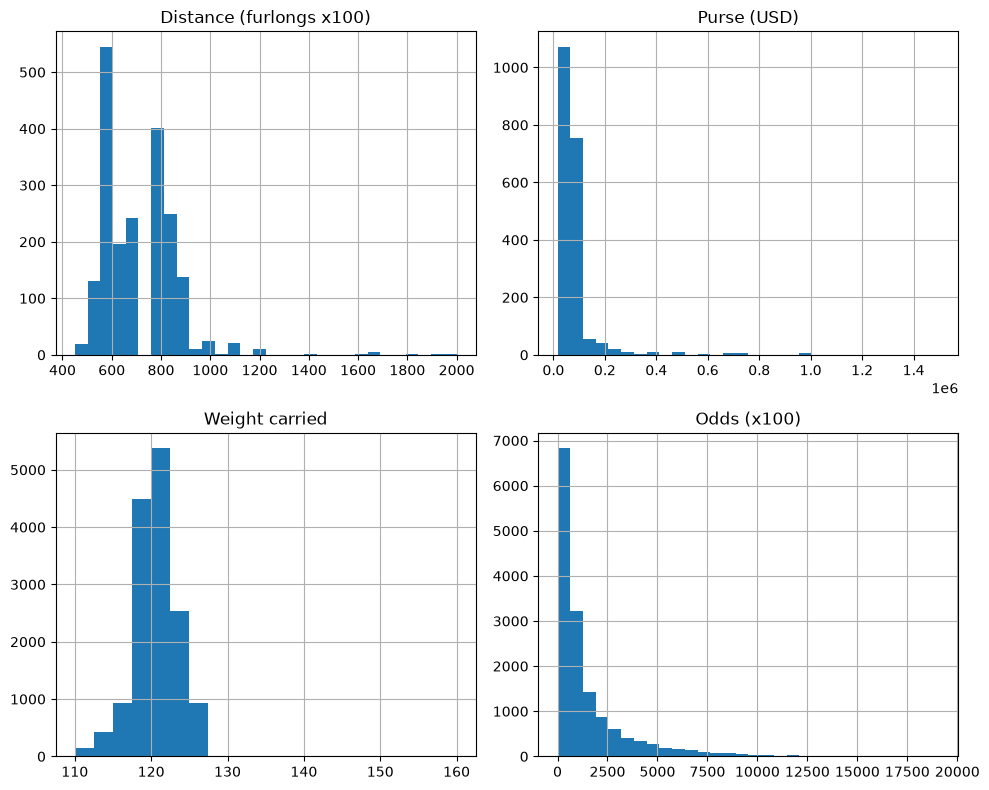

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

race["distance_id"].hist(ax=axes[0, 0], bins=30)
axes[0, 0].set_title("Distance (furlongs x100)")

race["purse"].hist(ax=axes[0, 1], bins=30)
axes[0, 1].set_title("Purse (USD)")

start["weight_carried"].hist(ax=axes[1, 0], bins=20)
axes[1, 0].set_title("Weight carried")

start["odds"].hist(ax=axes[1, 1], bins=30)
axes[1, 1].set_title("Odds (x100)")

plt.tight_layout()
plt.show()

`purse` and `odds` are both heavily right-skewed. Most races/horses cluster at the low end, with a long tail of a few large purses or long shots. `weight_carried` looks roughly normal. Worth remembering when we get to statistical testing in the next notebook: tests that assume normality won't be appropriate for purse or odds without transforming them first.

### 5.2 Categorical frequencies

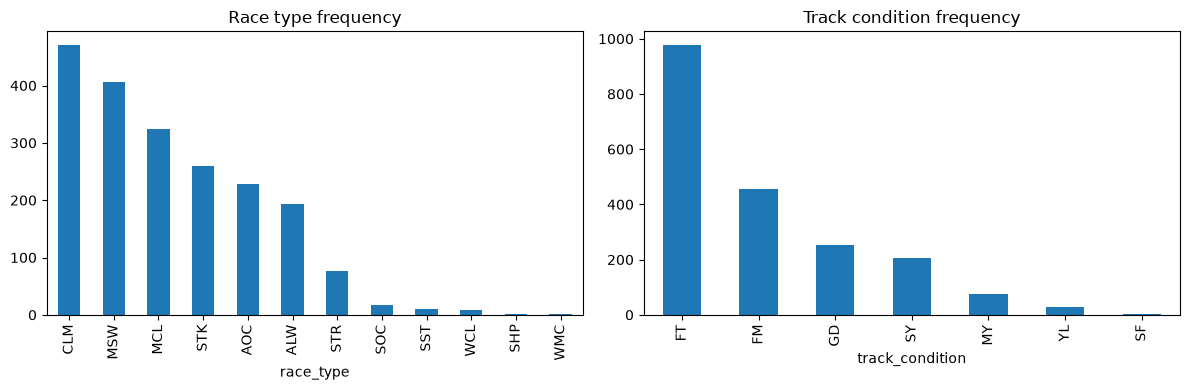

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

race["race_type"].value_counts().plot(kind="bar", ax=axes[0])
axes[0].set_title("Race type frequency")

race["track_condition"].value_counts().plot(kind="bar", ax=axes[1])
axes[1].set_title("Track condition frequency")

plt.tight_layout()
plt.show()

`race_type` is dominated by CLM, MSW, and MCL, the most common types of races (claiming and maiden races), since most horses run in these categories. STK (stakes, the prestigious races with the biggest purses) is comparatively rare, and SHP/WMC are nearly nonexistent (2 and 1 occurrences). This connects back to the purse skew seen earlier, most races have small purses because most races are claiming/maiden races, and only a handful of stakes races push the average up.

`track_condition` is dominated by FT (Fast, normal dry conditions), the default most of the year. MY, YL, and SF (wet/soft conditions) are rare by comparison.

### 5.3 Odds vs. finishing position

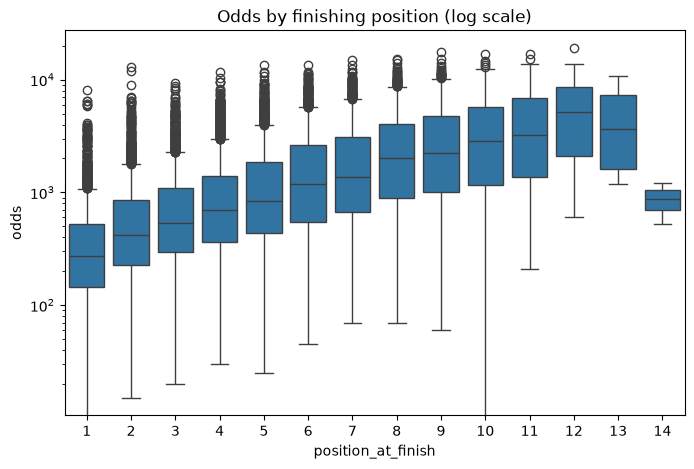

In [35]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=start, x="position_at_finish", y="odds")
plt.yscale("log")
plt.title("Odds by finishing position (log scale)")
plt.show()

Used a log scale here. Odds are skewed enough that a normal scale squashes everything into an unreadable mess. With the log scale, the pattern is clear and makes sense: horses that finish better tend to have had lower odds (were more favored by the market). Good sign that the data behaves the way a real betting market should. Useful context before trusting it for deeper analysis.

### 5.4 Weight carried vs. finishing position

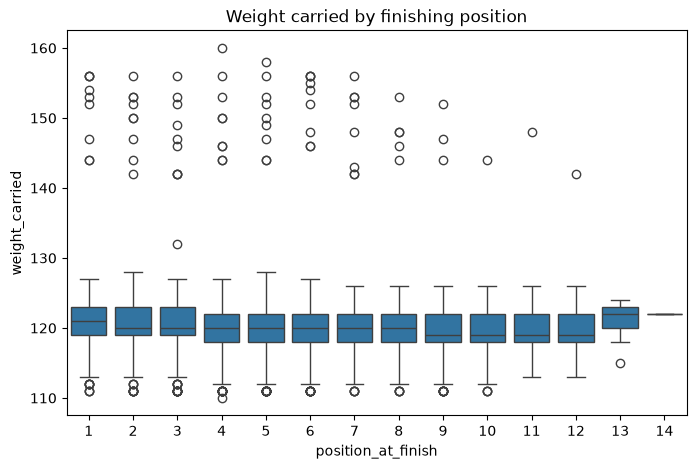

In [36]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=start, x="position_at_finish", y="weight_carried")
plt.title("Weight carried by finishing position")
plt.show()

At first glance it looks like horses finishing last carry less weight, especially in position 14. Checking the actual counts, though: position 14 has only 2 horses in the entire dataset, and position 13 has just 7, too few to draw any conclusion from. Looking at the median weight by position with proper sample sizes, the real pattern is a mild, gradual lbs decrease, not the dramatic shift the boxplot's tail suggested. Good reminder to check sample size before trusting a visual pattern.

## 6. Tracking table, domain-specific checks

### 6.1 Sampling density

Checking how many tracking frames each horse has per race. Should be fairly consistent given the ~4Hz sampling rate, with some natural variation depending on race length.

In [37]:
frame_counts = con.sql(f"""
    SELECT track_id, race_date, race_number, program_number, count(*) as n_frames
    FROM read_csv_auto('{RAW_DATA_DIR}/nyra_tracking_table.csv')
    GROUP BY 1,2,3,4
""").df()

frame_counts["n_frames"].describe()

count    14915.000000
mean       350.548441
std         75.318985
min          4.000000
25%        294.000000
50%        336.000000
75%        396.000000
max       1062.000000
Name: n_frames, dtype: float64

Average is around 350 frames (~90 seconds at 4Hz, reasonable for a typical race), but the minimum is just 4. Worth a closer look.

In [38]:
frame_counts[frame_counts["n_frames"] < 10]

,track_id,race_date,race_number,program_number,n_frames
2265,BEL,2019-07-06,3,3,4


One horse-race has only 4 frames instead of the usual ~350. Checking what happened with that horse in the start table. Did it actually run?

In [39]:
start[(start["track_id"] == "BEL") & (start["race_date"] == "2019-07-06") &
      (start["race_number"] == 3) & (start["program_number"] == "3")]

,track_id,race_date,race_number,program_number,weight_carried,jockey,odds,position_at_finish,program_number_base
9211,BEL,2019-07-06,3,3,124,Joel Rosario,180,6,3


The horse finished 6th. It ran the full race normally, so this isn't a scratched horse. The tracking data for this one horse-race is just incomplete, most likely a sensor or export issue. Flagging it: this specific horse-race should be excluded or handled carefully in any tracking-based feature built in the next notebook.

### 6.2 Geographic sanity check

Plotting a sample of tracking points by track, to confirm the three tracks show up as distinct, sensible clusters.

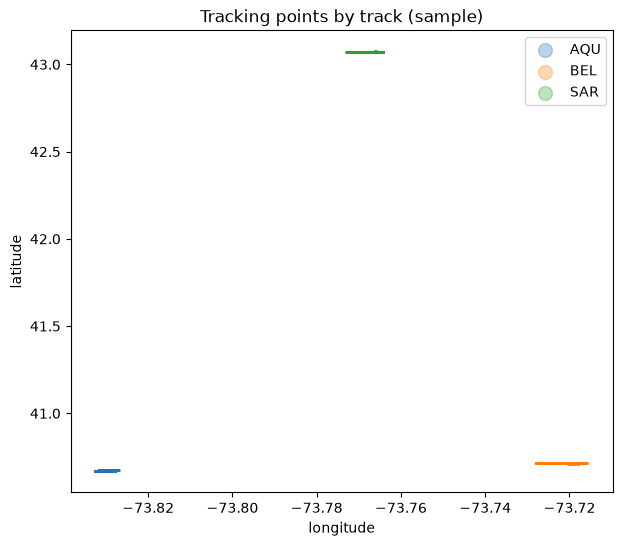

In [40]:
sample = con.sql(f"""
    SELECT track_id, latitude, longitude
    FROM read_csv_auto('{RAW_DATA_DIR}/nyra_tracking_table.csv')
    USING SAMPLE 50000 ROWS
""").df()

fig, ax = plt.subplots(figsize=(7, 6))
for track in sample["track_id"].unique():
    subset = sample[sample["track_id"] == track]
    ax.scatter(subset["longitude"], subset["latitude"], s=1, label=track, alpha=0.3)
ax.legend(markerscale=10)
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.set_title("Tracking points by track (sample)")
plt.show()

Three clearly separate clusters, matching the three tracks (Saratoga to the north, Aqueduct and Belmont close together near NYC). Nothing showing up in the wrong place.

### 6.3 Physical plausibility of speed

Calculating instantaneous speed between consecutive frames (distance between GPS points divided by the 0.25s sampling interval), to check for values that aren't physically possible for a horse. Those would point to GPS noise rather than real movement.

In [41]:
speed_check = con.sql(f"""
    WITH ordered AS (
        SELECT
            track_id, race_date, race_number, program_number, trakus_index,
            latitude, longitude,
            lag(latitude) OVER w AS prev_lat,
            lag(longitude) OVER w AS prev_lon
        FROM read_csv_auto('{RAW_DATA_DIR}/nyra_tracking_table.csv')
        WINDOW w AS (PARTITION BY track_id, race_date, race_number, program_number ORDER BY trakus_index)
    ),
    speeds AS (
        SELECT *,
            2 * 6371000 * asin(sqrt(
                pow(sin(radians(latitude - prev_lat)/2), 2) +
                cos(radians(prev_lat)) * cos(radians(latitude)) *
                pow(sin(radians(longitude - prev_lon)/2), 2)
            )) / 0.25 AS speed_ms
        FROM ordered
        WHERE prev_lat IS NOT NULL
    )
    SELECT
        count(*) as n,
        avg(speed_ms) as avg_speed,
        max(speed_ms) as max_speed,
        sum(case when speed_ms > 25 then 1 else 0 end) as n_above_25ms
    FROM speeds
""").df()
speed_check

,n,avg_speed,max_speed,n_above_25ms
0,5213515,18.45524,972.907961,1592.0


Average speed is about 18.5 m/s (~41 mph). A believable race pace for a thoroughbred. But the max is nearly 973 m/s, faster than the speed of sound, clearly impossible, and about 1,592 frames out of 5.2M (a small fraction) exceed 25 m/s, beyond what a horse can sustain. Points to GPS noise in a small number of frames, not real movement. We'll need to smooth or cap these before using speed as a feature in the next notebook. Noting it here, not fixing it now, since that's feature engineering, not data quality auditing.

## 7. Export clean data

In [42]:
race.to_parquet(PROCESSED_DATA_DIR / "race.parquet", index=False)
start.to_parquet(PROCESSED_DATA_DIR / "start.parquet", index=False)

Exporting tracking straight from the raw CSV via DuckDB, no point loading 340MB into pandas just to write it out. Applying the `program_number` strip here too, since this is the first time we write this table.

In [43]:
con.sql(f"""
    COPY (
        SELECT
            track_id,
            race_date,
            race_number,
            trim(program_number) AS program_number,
            trakus_index,
            latitude,
            longitude
        FROM read_csv_auto('{RAW_DATA_DIR}/nyra_tracking_table.csv')
    ) TO '{PROCESSED_DATA_DIR}/tracking.parquet' (FORMAT PARQUET)
""")

In [44]:
for filename in ["race.parquet", "start.parquet", "tracking.parquet"]:
    size_mb = (PROCESSED_DATA_DIR / filename).stat().st_size / 1e6
    print(f"{filename}: {size_mb:.1f} MB")

race.parquet: 0.0 MB
start.parquet: 0.1 MB
tracking.parquet: 81.2 MB


336 MB of CSV down to 81 MB as Parquet. Export looks clean.

## 8. Data quality findings, summary

- `nyra_start_table.csv` had no header row, column names assigned manually from the schema docs.
- `race.track_condition`: trailing space on all 2,000 rows. Stripped.
- `program_number` in both `start` and `tracking`: fixed-width padding on every row. Stripped.
- 3 rows in `start` have `odds = 0`, not a real market price. Exclude from any odds-based analysis.
- `program_number` suffixes like "1A" and "3X" are coupled entries (horses that bet as one unit). All 127 such groups share the same odds value, which confirms it. They're not independent observations for odds analysis.
- `race.post_time` is stored as a number with the leading zero dropped (e.g. 830 instead of 0830). No data lost, but needs re-padding if displayed as a time.
- All three tables join cleanly, no orphaned records.
- BEL, 2019-07-06, race 3, program 3: only 4 tracking frames for a horse that finished 6th. Looks like a sensor gap. Exclude or handle separately in any tracking feature.
- About 1,600 of 5.2M frame-to-frame speed calculations are physically impossible (max ~973 m/s). GPS noise in a tiny fraction of frames. Will need smoothing before using speed as a feature.